In [7]:
import pandas as pd
import matplotlib.pyplot as plt


Graphique 1 : CA Mensuel (ca_mensuel.png)

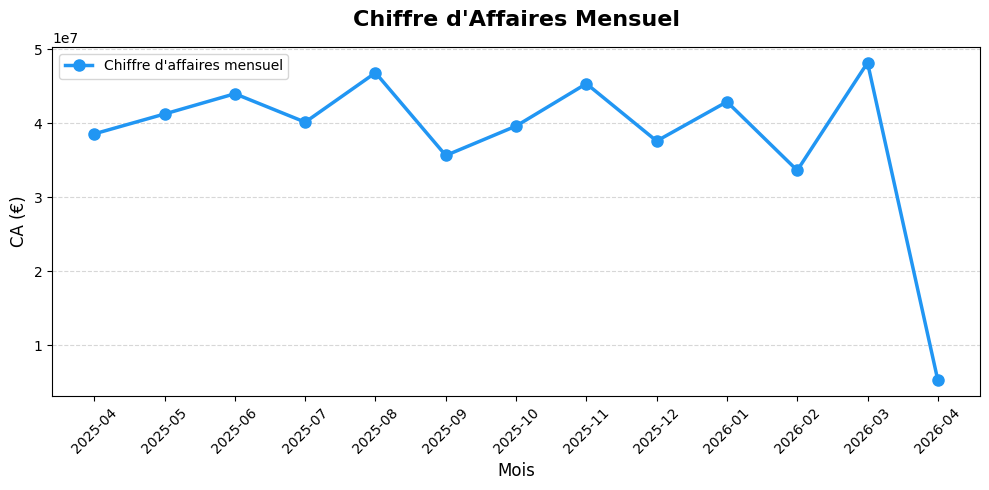

In [8]:

df_CA_mensuel=pd.read_csv("CA_mensuel.csv")
# Données KPI agrégées
mois = df_CA_mensuel["Mois"]
valeurs = df_CA_mensuel["Chiffre_affaire"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    mois,
    valeurs,
    color="#2196F3",
    linewidth=2.5,
    marker="o",
    markersize=8,
    label="Chiffre d'affaires mensuel"
)

ax.set_title("Chiffre d'Affaires Mensuel", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("CA (€)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Depuis le notebook dans outputs/, ce nom suffit
plt.savefig("ca_mensuel.png", dpi=150, bbox_inches="tight")
plt.show()

Graphique 2 : Top 5 Produits (top_produits.png)

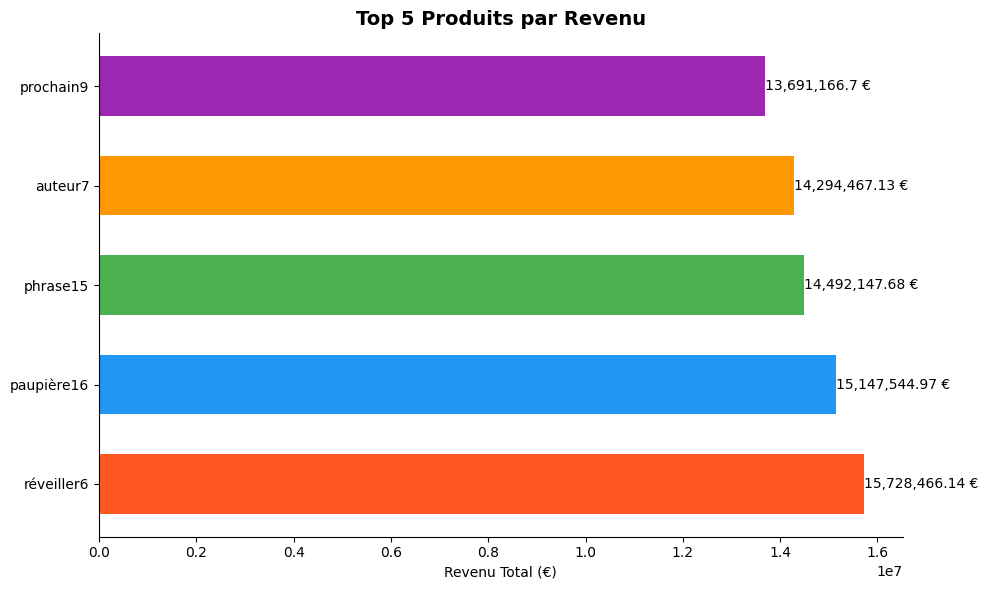

In [10]:
df_top_produits=pd.read_csv("top_produits.csv")
produits = df_top_produits["nom"]
revenues = df_top_produits["revenue"]
couleurs = ["#FF5722", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    produits,   # catégories sur l'axe Y (horizontal)
    revenues,   # valeurs sur l'axe X
    color=couleurs,
    height=0.6  # épaisseur des barres (0 à 1)
)
# Ajouter les valeurs au bout des barres
for bar, val in zip(bars, revenues):
    ax.text(
        bar.get_width() + 500,   # position X (légèrement après la barre)
        bar.get_y() + bar.get_height() / 2,  # position Y (centré)
        f"{val:,} €",            # texte formaté (virgule pour milliers)
        va="center", fontsize=10
    )
ax.set_title("Top 5 Produits par Revenu", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenu Total (€)")
ax.spines["top"].set_visible(False)    # supprime le cadre du haut
ax.spines["right"].set_visible(False)  # supprime le cadre de droite
plt.tight_layout()
plt.savefig("top_produits.png", dpi=150, bbox_inches="tight")
plt.show()


Graphique 3 : Top 10 Clients VIP (top_clients.png)

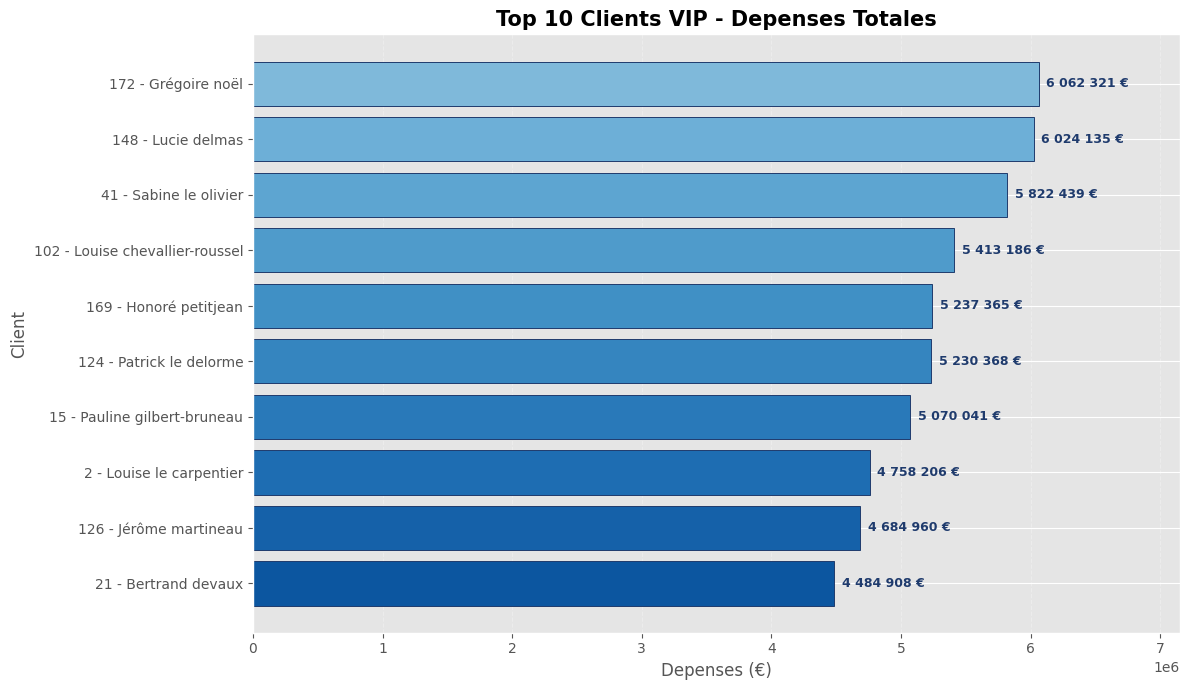

In [6]:
df_clients_vip = pd.read_csv("clients_vip.csv")

# On trie pour afficher clairement le classement du plus gros au plus faible
df_clients_vip = df_clients_vip.sort_values("depenses", ascending=False).head(10)

# Libelle compact: ID + nom pour rendre le graphe plus lisible
labels = [f"{cid} - {nom}" for cid, nom in zip(df_clients_vip["client_id"], df_clients_vip["nom"])]
depenses = df_clients_vip["depenses"]

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Blues([0.45 + i * 0.045 for i in range(len(depenses))])
bars = ax.barh(labels, depenses, color=colors, edgecolor="#1f3b6d", linewidth=0.7)

# Annotation des montants au bout de chaque barre
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + depenses.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f} €".replace(",", " "),
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#1f3b6d"
    )

ax.set_title("Top 10 Clients VIP - Depenses Totales", fontsize=15, fontweight="bold")
ax.set_xlabel("Depenses (€)")
ax.set_ylabel("Client")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.invert_yaxis()
ax.set_xlim(0, depenses.max() * 1.18)

plt.tight_layout()
plt.savefig("top_clients.png", dpi=170, bbox_inches="tight")
plt.show()